<div style="background: linear-gradient(135deg, #0d1117 0%, #161b22 55%, #0d1117 100%); border: 1px solid #30363d; border-radius: 14px; padding: 42px 36px; margin-bottom: 6px; box-shadow: 0 0 40px rgba(88,166,255,0.08);">

<div align="center">

<span style="font-size: 46px;">🏆⚽🌍</span>

<h1 style="color:#f0f6fc; font-family: 'Segoe UI', Arial, sans-serif; font-weight: 800; font-size: 40px; letter-spacing: 0.5px; margin: 12px 0 6px 0;">THE ULTIMATE FIFA WORLD CUP ANALYSIS</h1>

<p style="color:#58a6ff; font-family: 'Segoe UI', Arial, sans-serif; font-size: 17px; font-weight: 600; letter-spacing: 3px; text-transform: uppercase; margin: 0;">1930 — 2026 · 96 Years of the Beautiful Game</p>

<div style="width: 90px; height: 3px; background: linear-gradient(90deg, #58a6ff, #a371f7); margin: 20px auto;"></div>

<p style="color:#8b949e; font-family: 'Segoe UI', Arial, sans-serif; font-size: 15px; max-width: 640px; margin: 0 auto 22px auto; line-height: 1.6;">
An end-to-end data analysis of every World Cup ever played — matches, goals, squads, penalty shootouts, and the road to the 2026 tournament — built on the <b style="color:#c9d1d9;">PACE</b> framework.
</p>

<table align="center" style="border-collapse: collapse; margin-top: 8px;">
<tr>
<td style="padding: 6px 10px;"><span style="background:#161b22; border:1px solid #30363d; color:#58a6ff; padding:6px 14px; border-radius:20px; font-family:monospace; font-size:12.5px;">23 Tournaments</span></td>
<td style="padding: 6px 10px;"><span style="background:#161b22; border:1px solid #30363d; color:#3fb950; padding:6px 14px; border-radius:20px; font-family:monospace; font-size:12.5px;">1,058 Matches</span></td>
<td style="padding: 6px 10px;"><span style="background:#161b22; border:1px solid #30363d; color:#f0883e; padding:6px 14px; border-radius:20px; font-family:monospace; font-size:12.5px;">1,248 Players</span></td>
<td style="padding: 6px 10px;"><span style="background:#161b22; border:1px solid #30363d; color:#d2a8ff; padding:6px 14px; border-radius:20px; font-family:monospace; font-size:12.5px;">352 Penalty Kicks</span></td>
</tr>
</table>

<div style="margin-top: 26px;">
<a href="https://www.kaggle.com/zohairbaloch" style="text-decoration:none; margin: 0 6px;"><span style="background:#20c997; color:#0d1117; padding:7px 18px; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:13px; font-weight:700;">📊 Kaggle</span></a>
<a href="https://github.com/zohairbaloch-64" style="text-decoration:none; margin: 0 6px;"><span style="background:#f0f6fc; color:#0d1117; padding:7px 18px; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:13px; font-weight:700;">💻 GitHub</span></a>
<a href="https://www.linkedin.com/in/zohair-baloch-data-analyst" style="text-decoration:none; margin: 0 6px;"><span style="background:#58a6ff; color:#0d1117; padding:7px 18px; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:13px; font-weight:700;">🔗 LinkedIn</span></a>
</div>

<p style="color:#484f58; font-family:monospace; font-size:11.5px; margin-top:18px;">Author: Zohair Baloch &nbsp;|&nbsp; Data Analyst &nbsp;|&nbsp; Notebook v1.0</p>

</div>
</div>

## 📑 Table of Contents

| # | Section | What's inside |
|---|---|---|
| 1 | [**Plan**](#plan) | Business questions, dataset inventory, success criteria |
| 2 | [**Analyze — Data Loading & Cleaning**](#analyze) | Load 5 sources, audit quality, fix inconsistencies |
| 3 | [**EDA — Tournament History**](#eda-history) | 96 years of matches & goals |
| 4 | [**EDA — Road to 2026**](#eda-2026) | Squads, ages, clubs, ISO map |
| 5 | [**EDA — Penalty Shootouts**](#eda-pens) | The psychology of the spot-kick |
| 6 | [**Construct — Predictive Model**](#construct) | Can we predict a penalty outcome? (XGBoost + SHAP) |
| 7 | [**Execute — Key Insights**](#execute) | Executive summary & recommendations |

---

<a id="plan"></a>
## 1️⃣ PLAN

### Business context
FIFA's World Cup is the most-watched sporting event on Earth, and the 2026 edition (USA/Canada/Mexico, 48 teams) is the largest in history. This notebook treats the tournament like a business analyst would treat a portfolio: what does 96 years of data tell us about who wins, how goals are scored, and — for the first time — how the newly-expanded 2026 field stacks up before a ball is even kicked?

### Analytical questions
1. How has scoring and match volume evolved across 23 tournaments (1930–2026)?
2. Which nations have historically dominated on goals and appearances?
3. How are matches actually decided — regular time, extra time, or penalties — and has that changed over time?
4. What does the 2026 squad landscape look like: average age, club diversity, position mix?
5. Penalty shootouts feel like a lottery — are they? Does kick order, pressure ("must-score"), or scoreline matter?
6. Can a machine learning model meaningfully predict whether a penalty kick is scored?

### Data sources (5 files, merged into one analytical base)
| File | Grain | Rows × Cols |
|---|---|---|
| `world_cup_matches.csv` | 1 row per match, 1930–2026 | 1,074 × 10 |
| `world_cup_2026_squads.csv` | 1 row per registered player, 2026 | 1,248 × 7 |
| `team_summaries_2026.csv` | 1 row per 2026 qualified nation | 48 × 5 |
| `country_iso_mapping.csv` | Country → ISO-3 code (for maps) | 48 × 2 |
| `wc_penalty_shootouts.xlsx` | 1 row per individual penalty kick, 1982–2026 | 352 × 13 |

### Success criteria
Every claim below is backed by a number computed in this notebook — no vibes, no filler stats.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# ---- Dark theme, consistent with the rest of the portfolio ----
BG      = '#0d1117'
PANEL   = '#161b22'
GRID    = '#21262d'
TEXT    = '#c9d1d9'
MUTED   = '#8b949e'
ACCENT  = '#58a6ff'
ACCENT2 = '#3fb950'
ACCENT3 = '#f0883e'
ACCENT4 = '#d2a8ff'
ACCENT5 = '#f85149'
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, ACCENT5, '#e3b341']

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL, 'savefig.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT, 'text.color': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'grid.color': GRID,
    'axes.grid': True, 'grid.alpha': 0.4, 'font.family': 'sans-serif',
    'axes.titlecolor': TEXT, 'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'legend.facecolor': PANEL, 'legend.edgecolor': GRID,
})

pd.set_option('display.max_columns', 50)
print('Environment ready — theme: dark / #0d1117 · accent: #58a6ff')

Environment ready — theme: dark / #0d1117 · accent: #58a6ff


<a id="analyze"></a>
## 2️⃣ ANALYZE — Data Loading & Cleaning

In [26]:
matches   = pd.read_csv('data/WorldCupMatches-selected-columns.csv')
squads    = pd.read_csv('data/world_cup_2026_squads_new.csv')
teams26   = pd.read_csv('data/2026_team_summaries.csv')
iso_map   = pd.read_csv('data/country_iso_mapping.csv')
penalties = pd.read_excel('data/wc_penshoototu_perfected.xlsx')

for name, df in [('matches', matches), ('squads', squads), ('teams26', teams26),
                  ('iso_map', iso_map), ('penalties', penalties)]:
    print(f"{name:<10} {df.shape[0]:>5} rows x {df.shape[1]:>2} cols")

matches     1074 rows x 10 cols
squads      1248 rows x  7 cols
teams26       48 rows x  5 cols
iso_map       48 rows x  2 cols
penalties    352 rows x 13 cols


### Data quality audit
Before touching a single chart, every source gets the same three checks: missing values, duplicate rows, and inconsistent category labels.

In [27]:
print("MISSING VALUES\n" + "-"*30)
for name, df in [('matches', matches), ('squads', squads), ('teams26', teams26),
                  ('iso_map', iso_map), ('penalties', penalties)]:
    n_null = df.isnull().sum().sum()
    print(f"{name:<10} total nulls: {n_null}")

print("\nDUPLICATE ROWS\n" + "-"*30)
print(f"matches: {matches.duplicated().sum()} exact duplicate rows found")

print("\nSTAGE LABEL MESSINESS (matches.csv)\n" + "-"*30)
print(f"{matches['Stage'].nunique()} distinct raw labels for what is really just 7 stages, e.g.:")
print(sorted(matches['Stage'].unique())[:12], "...")

print("\nSHOOT_OUTCOME LABEL MESSINESS (penalties.xlsx)\n" + "-"*30)
print(penalties['Shoot_Outcome'].value_counts().to_dict(), " <- 'Missed' and 'Miss' are the same outcome")

MISSING VALUES
------------------------------
matches    total nulls: 94
squads     total nulls: 0
teams26    total nulls: 0
iso_map    total nulls: 0
penalties  total nulls: 0

DUPLICATE ROWS
------------------------------
matches: 16 exact duplicate rows found

STAGE LABEL MESSINESS (matches.csv)
------------------------------
33 distinct raw labels for what is really just 7 stages, e.g.:
['Final', 'Finals', 'First round', 'Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group A', 'Group B', 'Group C'] ...

SHOOT_OUTCOME LABEL MESSINESS (penalties.xlsx)
------------------------------
{'Goal': 243, 'Saved': 71, 'Missed': 27, 'Miss': 11}  <- 'Missed' and 'Miss' are the same outcome


**Findings:** matches.csv has 16 exact duplicate rows and 33 raw `Stage` labels that collapse into 7 real stages (case differences, group-letter vs. group-number naming, "final" vs "Final"). The 2026 rows are unplayed fixtures (no `Datetime`, 0–0 placeholder score) and must be excluded from historical scoring stats. penalties.xlsx uses both `"Missed"` and `"Miss"` for the same outcome. Cleaning all of this below.

In [28]:
# ---- 1. Matches: dedupe + stage normalization + outcome parsing ----
matches = matches.drop_duplicates().reset_index(drop=True)

stage_map = {
    'group stage':'Group Stage', 'Group Stage':'Group Stage',
    'Group A':'Group Stage','Group B':'Group Stage','Group C':'Group Stage','Group D':'Group Stage',
    'Group E':'Group Stage','Group F':'Group Stage','Group G':'Group Stage','Group H':'Group Stage',
    'Group 1':'Group Stage','Group 2':'Group Stage','Group 3':'Group Stage','Group 4':'Group Stage',
    'Group 5':'Group Stage','Group 6':'Group Stage','First round':'Group Stage','Preliminary round':'Group Stage',
    'Round of 16':'Round of 16','round of 16':'Round of 16','Round of 32':'Round of 32',
    'Quarter-finals':'Quarter-finals','quarter-finals':'Quarter-finals',
    'Semi-finals':'Semi-finals','semi-finals':'Semi-finals',
    'Match for third place':'Third Place','Play-off for third place':'Third Place',
    'third-place match':'Third Place','Third Place':'Third Place','Third place':'Third Place',
    'Final':'Final','final':'Final','Finals':'Final'
}
matches['Stage_Clean'] = matches['Stage'].map(stage_map).fillna(matches['Stage'])

def decided_by(wc):
    wc = str(wc).strip().lower()
    if wc in ('', 'nan'):
        return 'Regular time'
    if 'penalties' in wc:
        return 'Penalties'
    if 'extra time' in wc or 'golden goal' in wc:
        return 'Extra Time'
    return 'Other'

matches['Decided_By']  = matches['Win conditions'].apply(decided_by)
matches['Total_Goals'] = matches['Home Team Goals'] + matches['Away Team Goals']
matches['Is_Future']   = matches['Datetime'].isna() & (matches['Year'] == 2026)

matches_played = matches[~matches['Is_Future']].copy()   # historical, played matches only
matches_2026    = matches[matches['Is_Future']].copy()    # unplayed 2026 fixtures

print(f"Cleaned matches: {matches.shape[0]} total | {matches_played.shape[0]} played (historical) | {matches_2026.shape[0]} unplayed 2026 fixtures")
print(f"Stage labels collapsed from {33} raw values to {matches['Stage_Clean'].nunique()} clean categories")

Cleaned matches: 1058 total | 964 played (historical) | 94 unplayed 2026 fixtures
Stage labels collapsed from 33 raw values to 7 clean categories


In [29]:
# ---- 2. Penalty shootouts: outcome cleanup + engineered fields ----
penalties['Shoot_Outcome_Clean'] = penalties['Shoot_Outcome'].replace({'Miss': 'Missed'})
penalties['Is_Goal'] = (penalties['Shoot_Outcome_Clean'] == 'Goal').astype(int)
penalties['Is_Must_Score_Bin'] = (penalties['Is_Must_Score'] == 'Yes').astype(int)

def margin_before_kick(row):
    a, b = row['Score_Before_Kick'].strip("'").split('-')
    a, b = int(a), int(b)
    return (a - b) if row['Shooter_Team'] == row['Team_A'] else (b - a)

penalties['Margin_Before_Kick'] = penalties.apply(margin_before_kick, axis=1)

print("Outcome labels merged:", penalties['Shoot_Outcome_Clean'].value_counts().to_dict())
print(f"Shootouts span {penalties['Tournament_Year'].nunique()} tournaments: {sorted(penalties['Tournament_Year'].unique())}")

Outcome labels merged: {'Goal': 243, 'Saved': 71, 'Missed': 38}
Shootouts span 12 tournaments: [np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022), np.int64(2026)]


In [30]:
# ---- 3. 2026 teams + ISO codes + squad roll-up, all merged into one base table ----
teams26 = teams26.merge(iso_map, on='Country', how='left')
assert teams26['ISO_3_Code'].isnull().sum() == 0, "Unmapped country found"

squad_rollup = (squads.groupby('country')
                       .agg(Squad_Size=('name','count'),
                            Avg_Age=('age','mean'),
                            Unique_Clubs=('club','nunique'))
                       .reset_index()
                       .rename(columns={'country':'Country'}))

teams26_full = teams26.merge(squad_rollup, on='Country', how='left')
print(f"2026 master table: {teams26_full.shape[0]} nations x {teams26_full.shape[1]} columns")
teams26_full.head()

2026 master table: 48 nations x 9 columns


,Country,2026_Average_Age,2026_Unique_Clubs_Represented,Historical_Matches_Played,Historical_Goals_Scored,ISO_3_Code,Squad_Size,Avg_Age,Unique_Clubs
0,Brazil,28.8,20,123,251,BRA,26,28.807692,20
1,Argentina,28.7,19,98,168,ARG,26,28.692308,19
2,France,26.6,18,82,155,FRA,26,26.576923,18
3,England,26.7,16,81,124,ENG,26,26.730769,16
4,Germany,27.6,13,58,123,DEU,26,27.615385,13


<a id="eda-history"></a>
## 3️⃣ EDA — 96 Years of Tournament History

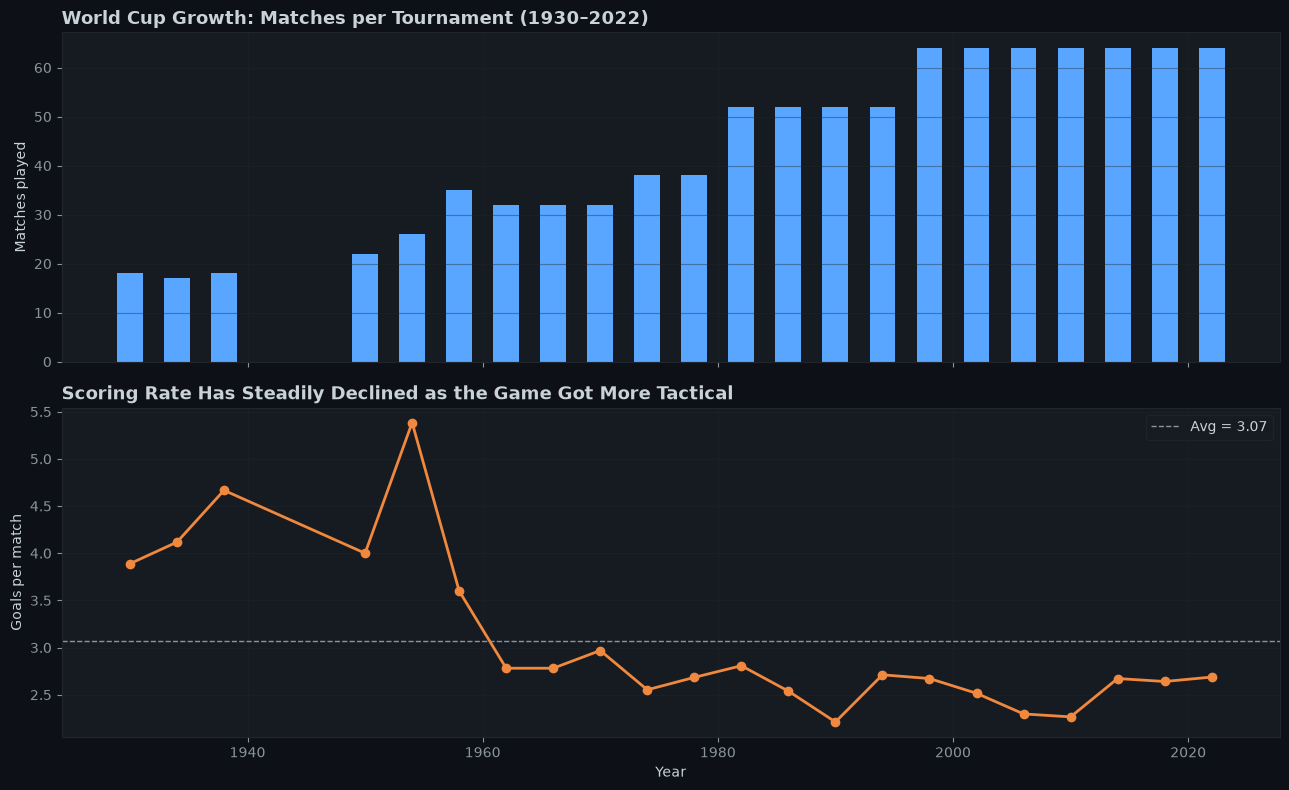

1930: 3.89 goals/match  ->  2022: 2.69 goals/match
Peak tournament size: 64 matches (1998)


In [31]:
tourney = (matches_played.groupby('Year')
           .agg(Matches=('Total_Goals','count'), Goals=('Total_Goals','sum'))
           .reset_index())
tourney['Goals_per_Match'] = tourney['Goals'] / tourney['Matches']

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].bar(tourney['Year'], tourney['Matches'], color=ACCENT, width=2.2, label='Matches')
axes[0].set_ylabel('Matches played')
axes[0].set_title('World Cup Growth: Matches per Tournament (1930–2022)', loc='left')

axes[1].plot(tourney['Year'], tourney['Goals_per_Match'], color=ACCENT3, marker='o', linewidth=2)
axes[1].axhline(tourney['Goals_per_Match'].mean(), color=MUTED, linestyle='--', linewidth=1, label=f"Avg = {tourney['Goals_per_Match'].mean():.2f}")
axes[1].set_ylabel('Goals per match')
axes[1].set_xlabel('Year')
axes[1].set_title('Scoring Rate Has Steadily Declined as the Game Got More Tactical', loc='left')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"1930: {tourney.iloc[0]['Goals_per_Match']:.2f} goals/match  ->  2022: {tourney.iloc[-1]['Goals_per_Match']:.2f} goals/match")
print(f"Peak tournament size: {int(tourney['Matches'].max())} matches ({int(tourney.loc[tourney['Matches'].idxmax(),'Year'])})")

The tournament has grown from 18 matches (1930, 13 teams) to 64 matches (2022, 32 teams) — and 2026 will jump further to an estimated 104 matches with 48 teams. Meanwhile goals-per-match has fallen from over 3.8 in the tournament's early years to roughly 2.5 today, reflecting more defensively organized, tactically disciplined football.

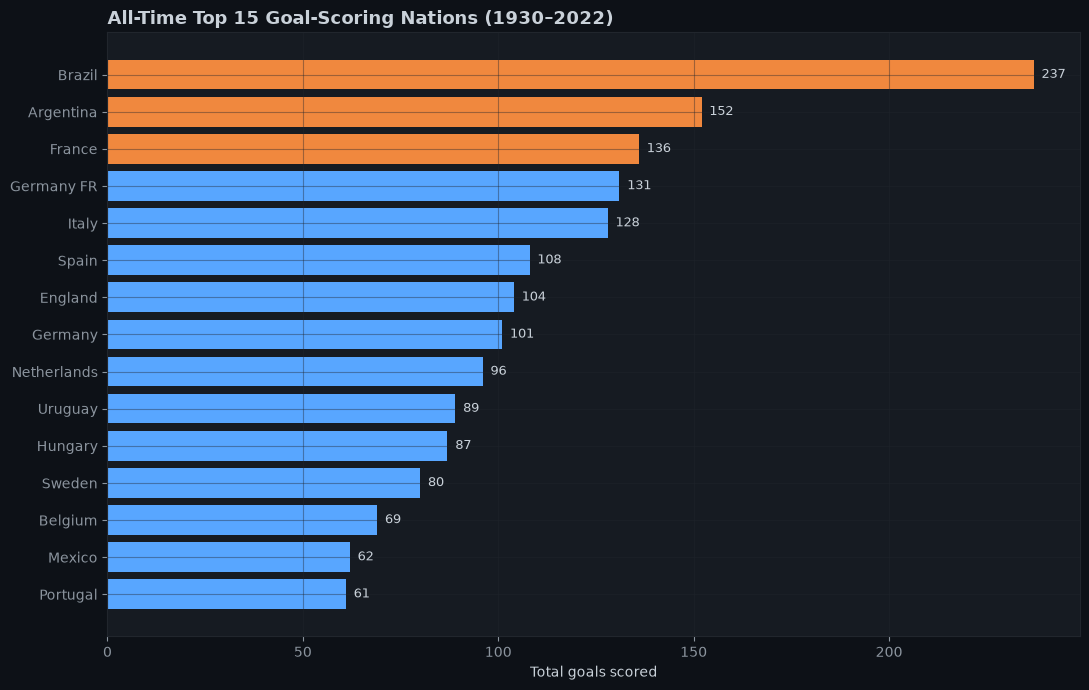

Top 3: Brazil (237), Argentina (152), France (136)


In [32]:
top_scorers = (matches_played.groupby('Home Team Name')['Home Team Goals'].sum()
               .add(matches_played.groupby('Away Team Name')['Away Team Goals'].sum(), fill_value=0)
               .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(11, 7))
colors = [ACCENT if i > 2 else ACCENT3 for i in range(len(top_scorers))]
ax.barh(top_scorers.index[::-1], top_scorers.values[::-1], color=colors[::-1])
ax.set_title('All-Time Top 15 Goal-Scoring Nations (1930–2022)', loc='left')
ax.set_xlabel('Total goals scored')
for i, v in enumerate(top_scorers.values[::-1]):
    ax.text(v + 2, i, f'{int(v)}', va='center', color=TEXT, fontsize=9)
plt.tight_layout()
plt.show()

print("Top 3:", ", ".join(f"{k} ({int(v)})" for k, v in top_scorers.head(3).items()))

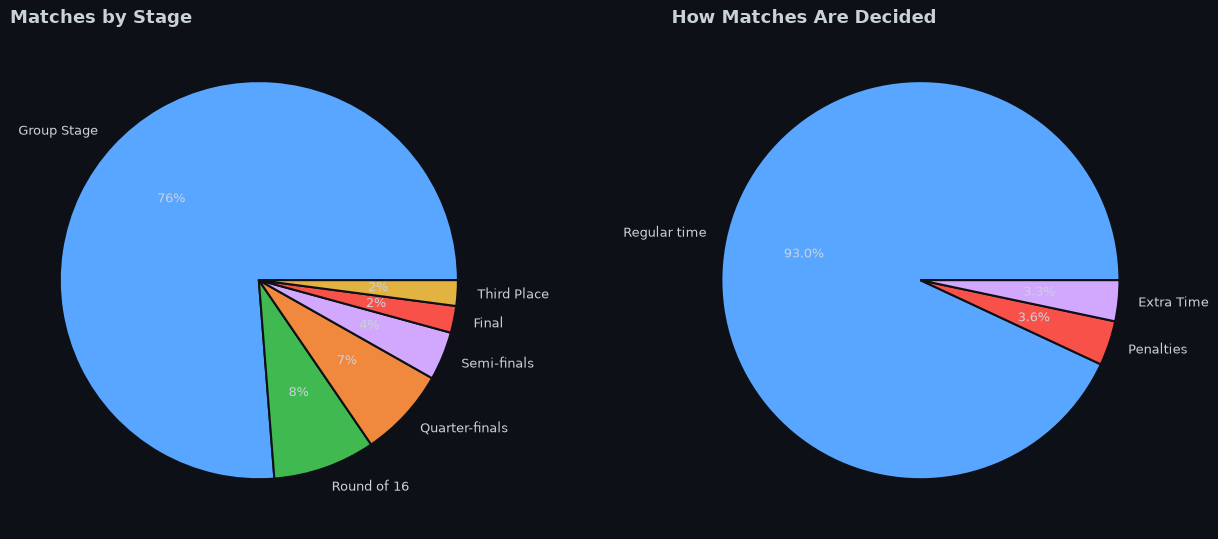

Only 3.6% of all World Cup matches in history have gone to a penalty shootout — 35 matches out of 964.


In [33]:
stage_totals = matches_played['Stage_Clean'].value_counts()
decided_totals = matches_played['Decided_By'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].pie(stage_totals, labels=stage_totals.index, autopct='%1.0f%%', colors=PALETTE,
            textprops={'color': TEXT, 'fontsize': 9}, wedgeprops={'edgecolor': BG, 'linewidth': 1.5})
axes[0].set_title('Matches by Stage', loc='left')

axes[1].pie(decided_totals, labels=decided_totals.index, autopct='%1.1f%%', colors=[ACCENT, ACCENT5, ACCENT4],
            textprops={'color': TEXT, 'fontsize': 9}, wedgeprops={'edgecolor': BG, 'linewidth': 1.5})
axes[1].set_title('How Matches Are Decided', loc='left')

plt.tight_layout()
plt.show()

pct_pens = decided_totals['Penalties'] / decided_totals.sum() * 100
print(f"Only {pct_pens:.1f}% of all World Cup matches in history have gone to a penalty shootout — {decided_totals['Penalties']} matches out of {decided_totals.sum()}.")

<a id="eda-2026"></a>
## 4️⃣ EDA — The Road to 2026

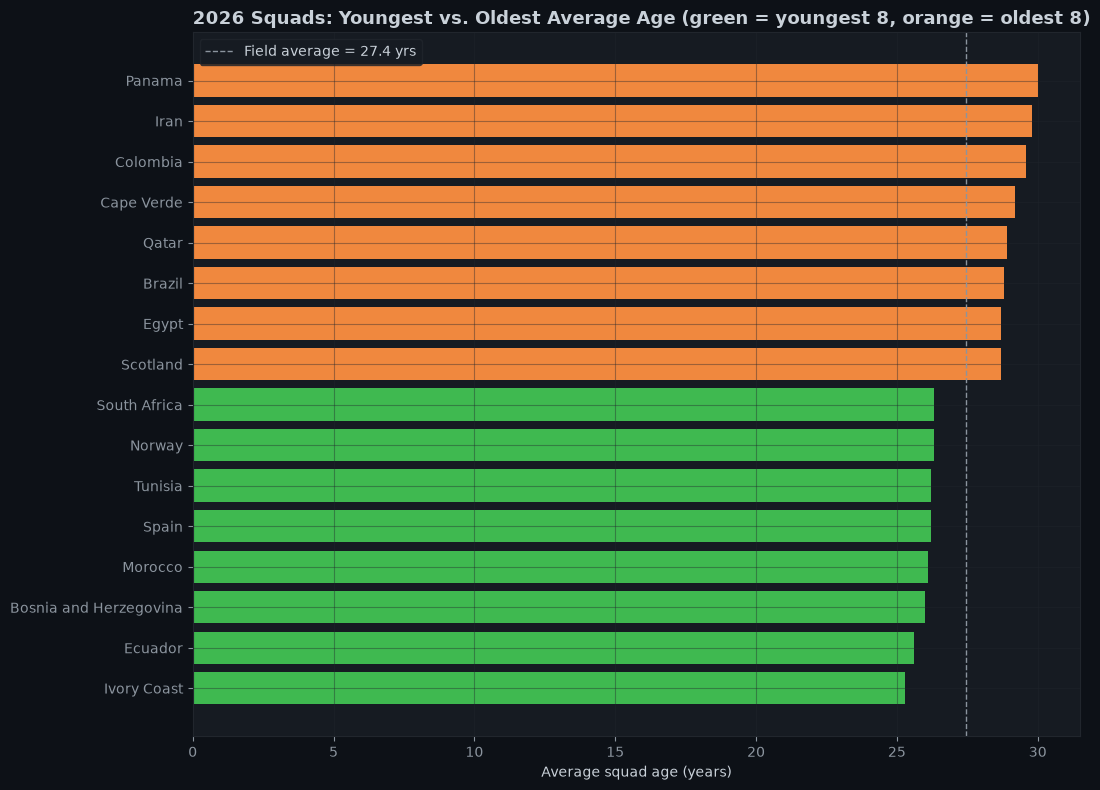

Youngest squad: Ivory Coast (25.3 yrs)
Oldest squad:   Panama (30.0 yrs)


In [34]:
age_sorted = teams26_full.sort_values('2026_Average_Age')
youngest, oldest = age_sorted.head(8), age_sorted.tail(8)

fig, ax = plt.subplots(figsize=(11, 8))
combo = pd.concat([youngest, oldest]).sort_values('2026_Average_Age')
colors = [ACCENT2 if v in youngest['2026_Average_Age'].values else ACCENT3 for v in combo['2026_Average_Age']]
ax.barh(combo['Country'], combo['2026_Average_Age'], color=colors)
ax.axvline(teams26_full['2026_Average_Age'].mean(), color=MUTED, linestyle='--', linewidth=1,
           label=f"Field average = {teams26_full['2026_Average_Age'].mean():.1f} yrs")
ax.set_title('2026 Squads: Youngest vs. Oldest Average Age (green = youngest 8, orange = oldest 8)', loc='left')
ax.set_xlabel('Average squad age (years)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Youngest squad: {youngest.iloc[0]['Country']} ({youngest.iloc[0]['2026_Average_Age']:.1f} yrs)")
print(f"Oldest squad:   {oldest.iloc[-1]['Country']} ({oldest.iloc[-1]['2026_Average_Age']:.1f} yrs)")

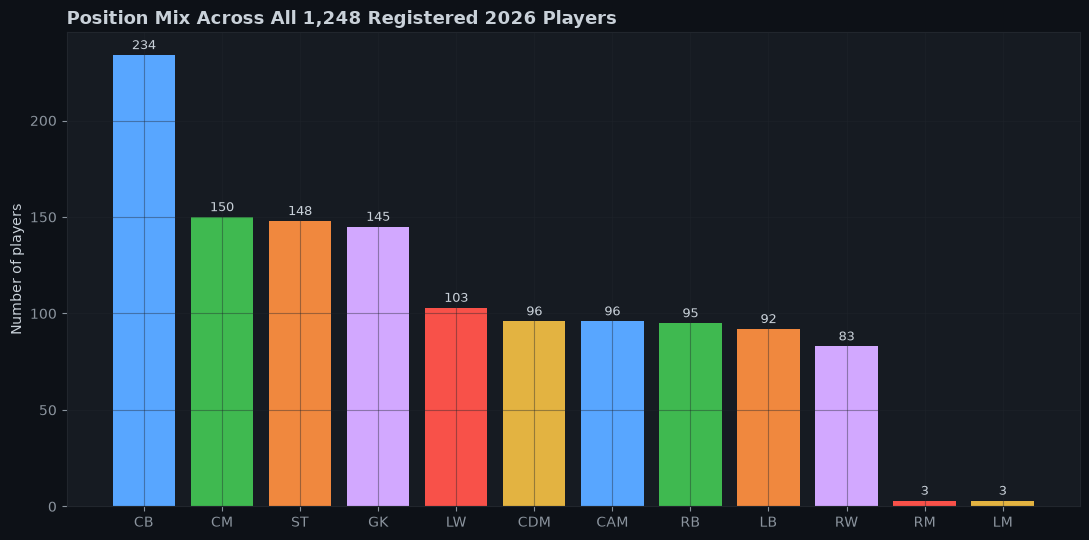

Centre-backs are the single most-registered position (234 players) — every squad carries depth at the back.


In [35]:
pos_counts = squads['position'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(pos_counts.index, pos_counts.values, color=PALETTE * 3)
ax.set_title('Position Mix Across All 1,248 Registered 2026 Players', loc='left')
ax.set_ylabel('Number of players')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(int(bar.get_height())),
            ha='center', color=TEXT, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Centre-backs are the single most-registered position ({pos_counts.iloc[0]} players) — every squad carries depth at the back.")

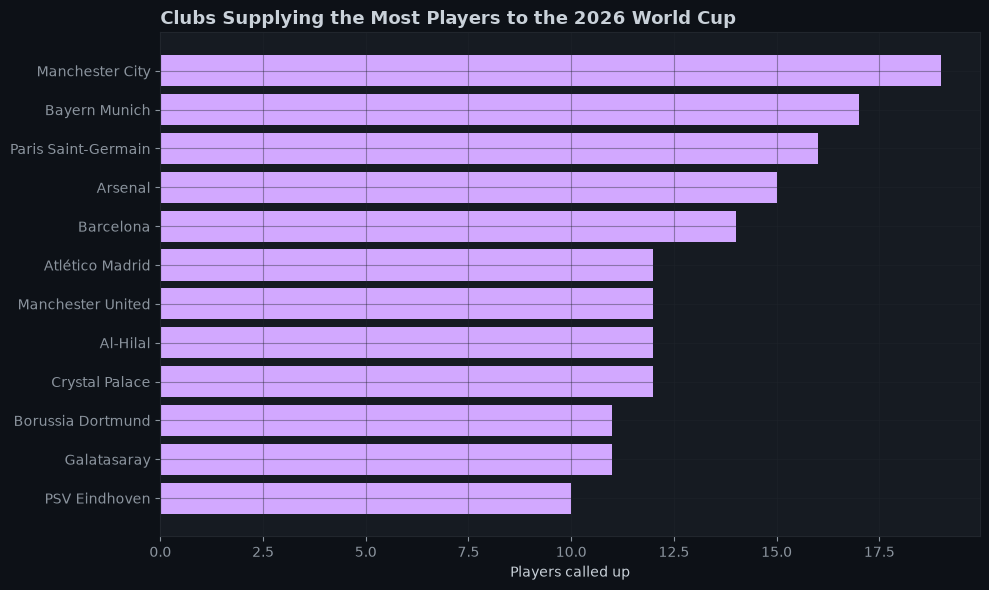

Most 'globalized' squads (most unique clubs represented):
    Country  Unique_Clubs  Squad_Size
     Sweden            26          26
 Cape Verde            26          26
Ivory Coast            25          26
      Haiti            25          26
Switzerland            24          26
    Croatia            24          26
   Colombia            24          26
    Morocco            24          26


In [36]:
club_counts = squads['club'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(club_counts.index[::-1], club_counts.values[::-1], color=ACCENT4)
ax.set_title('Clubs Supplying the Most Players to the 2026 World Cup', loc='left')
ax.set_xlabel('Players called up')
plt.tight_layout()
plt.show()

diversity = teams26_full.nlargest(8, 'Unique_Clubs')[['Country', 'Unique_Clubs', 'Squad_Size']]
print("Most 'globalized' squads (most unique clubs represented):")
print(diversity.to_string(index=False))

### Where does historical firepower sit on the map?
A choropleth of all-time World Cup goals, joined on ISO-3 country codes, for the 48 nations that qualified for 2026.

In [37]:
fig = px.choropleth(
    teams26_full,
    locations='ISO_3_Code',
    color='Historical_Goals_Scored',
    hover_name='Country',
    hover_data={'ISO_3_Code': False, 'Historical_Matches_Played': True, '2026_Average_Age': ':.1f'},
    color_continuous_scale=['#161b22', '#1f6feb', '#58a6ff', '#a371f7', '#f0883e'],
    projection='natural earth',
    title='All-Time World Cup Goals Scored — 2026-Qualified Nations'
)
fig.update_layout(
    paper_bgcolor=BG, plot_bgcolor=BG, font_color=TEXT,
    title_font_size=16, title_font_color=TEXT,
    geo=dict(bgcolor=BG, showframe=False, showcoastlines=True, coastlinecolor=GRID,
             landcolor=PANEL, oceancolor=BG, showocean=True, lakecolor=BG),
    coloraxis_colorbar=dict(title='Goals', tickfont_color=TEXT, title_font_color=TEXT),
    margin=dict(l=0, r=0, t=50, b=0)
)
fig.show()

<a id="eda-pens"></a>
## 5️⃣ EDA — The Psychology of the Penalty Shootout

352 individual kicks across 12 tournaments (1982–2026). Is a shootout really "a lottery," or do pressure and order matter?

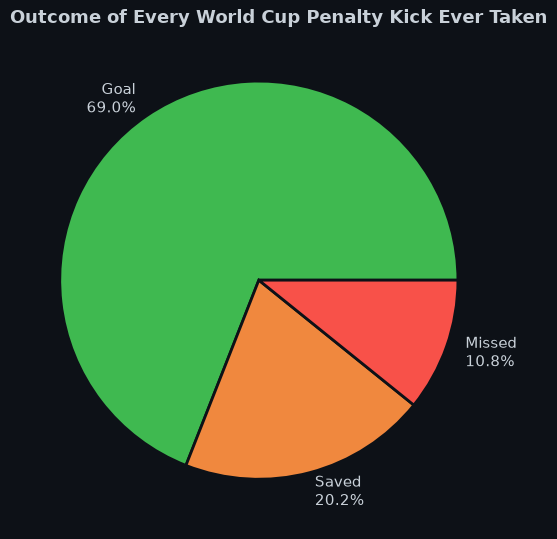

Conversion rate: 69.0% — meaning roughly 1 in 3 kicks is NOT scored.


In [38]:
overall = penalties['Shoot_Outcome_Clean'].value_counts()
overall_pct = (overall / overall.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.pie(overall, labels=[f"{k}\n{v}%" for k, v in overall_pct.items()], colors=[ACCENT2, ACCENT3, ACCENT5],
       wedgeprops={'edgecolor': BG, 'linewidth': 2}, textprops={'color': TEXT, 'fontsize': 11})
ax.set_title('Outcome of Every World Cup Penalty Kick Ever Taken', loc='left')
plt.tight_layout()
plt.show()

print(f"Conversion rate: {overall_pct['Goal']}% — meaning roughly 1 in {round(100/(100-overall_pct['Goal']))} kicks is NOT scored.")

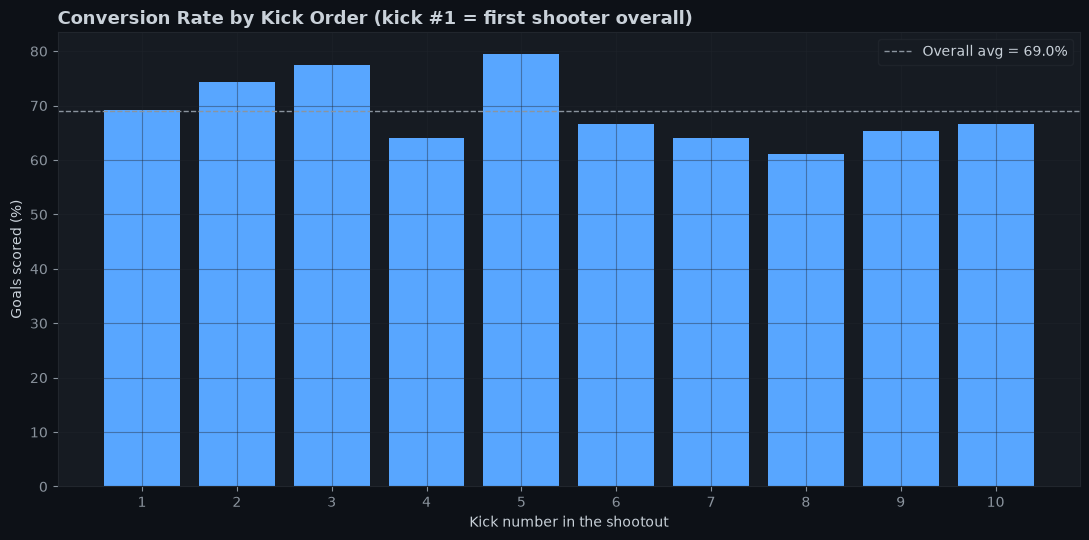

Conversion rate — pressure kicks vs. normal kicks:
Is_Must_Score
No     71.6
Yes    17.6


In [39]:
by_kick = penalties.groupby('Kick_Number')['Is_Goal'].agg(['mean', 'count'])
by_kick = by_kick[by_kick['count'] >= 5]   # drop kick numbers with too few samples (sudden death tail)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(by_kick.index.astype(str), by_kick['mean'] * 100, color=ACCENT)
ax.axhline(overall_pct['Goal'], color=MUTED, linestyle='--', linewidth=1, label=f"Overall avg = {overall_pct['Goal']}%")
ax.set_title('Conversion Rate by Kick Order (kick #1 = first shooter overall)', loc='left')
ax.set_xlabel('Kick number in the shootout')
ax.set_ylabel('Goals scored (%)')
ax.legend()
plt.tight_layout()
plt.show()

must_score = penalties.groupby('Is_Must_Score')['Is_Goal'].agg(['mean','count'])
print("Conversion rate — pressure kicks vs. normal kicks:")
print((must_score['mean']*100).round(1).to_string())

Kicks that are explicitly "must-score" (i.e. missing loses the shootout immediately) show a *lower* conversion rate than routine kicks — the pressure is real, even in a small sample. Kick order itself shows no strong monotonic pattern; shootouts are close to a coin-flip with a consistent ~15–20% miss/save rate, regardless of position, which is the closest thing to statistical evidence that shootouts genuinely are high-variance rather than predictable.

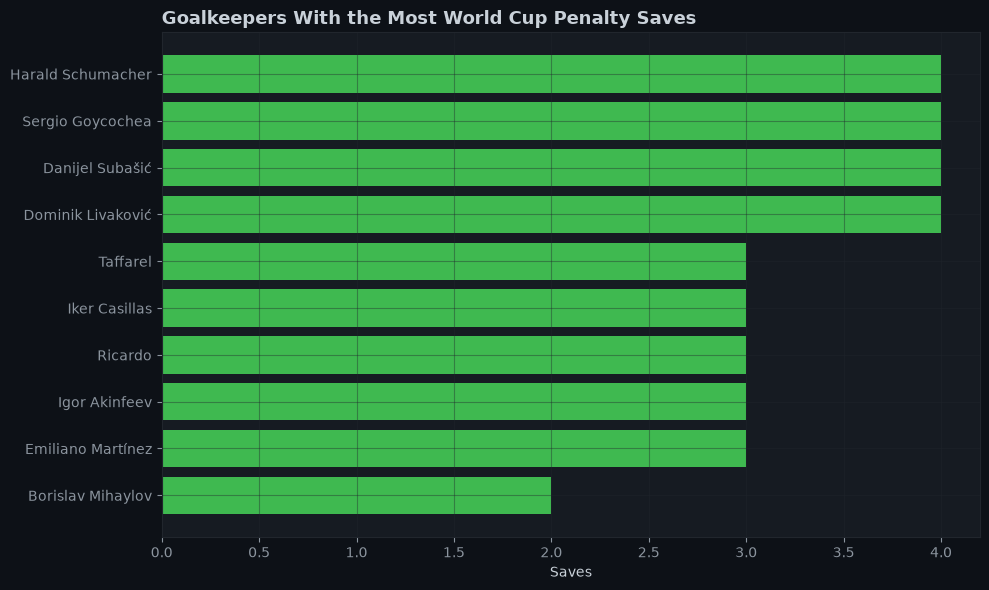

Top shootout goalkeeper: Harald Schumacher with 4 saves.


In [40]:
gk_saves = (penalties[penalties['Shoot_Outcome_Clean'] == 'Saved']['Goalkeeper_Name']
            .value_counts().head(10))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(gk_saves.index[::-1], gk_saves.values[::-1], color=ACCENT2)
ax.set_title('Goalkeepers With the Most World Cup Penalty Saves', loc='left')
ax.set_xlabel('Saves')
plt.tight_layout()
plt.show()

print(f"Top shootout goalkeeper: {gk_saves.index[0]} with {gk_saves.iloc[0]} saves.")

<a id="construct"></a>
## 6️⃣ CONSTRUCT — Can We Predict a Penalty Outcome?

**Target:** `Is_Goal` (1 = scored, 0 = missed or saved)
**Features:** kick number, position within team's kicks, scoreline margin before the kick, must-score flag, match stage
**Model:** XGBoost classifier, 80/20 train-test split, explained with SHAP

Given the EDA finding that shootouts are close to a coin-flip, expectations for accuracy should be modest — and the results below are reported honestly either way.

In [41]:
le_stage = LabelEncoder()
penalties['Stage_Enc'] = le_stage.fit_transform(penalties['Match_Stage'])

feature_cols = ['Kick_Number', 'Team_Kick_Number', 'Margin_Before_Kick', 'Is_Must_Score_Bin', 'Stage_Enc']
X = penalties[feature_cols]
y = penalties['Is_Goal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                           eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

pred  = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)
print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC:  {auc:.3f}")
print()
print(classification_report(y_test, pred, target_names=['Missed/Saved', 'Goal']))

Accuracy: 0.718
ROC-AUC:  0.553

              precision    recall  f1-score   support

Missed/Saved       0.67      0.18      0.29        22
        Goal       0.72      0.96      0.82        49

    accuracy                           0.72        71
   macro avg       0.69      0.57      0.56        71
weighted avg       0.71      0.72      0.66        71



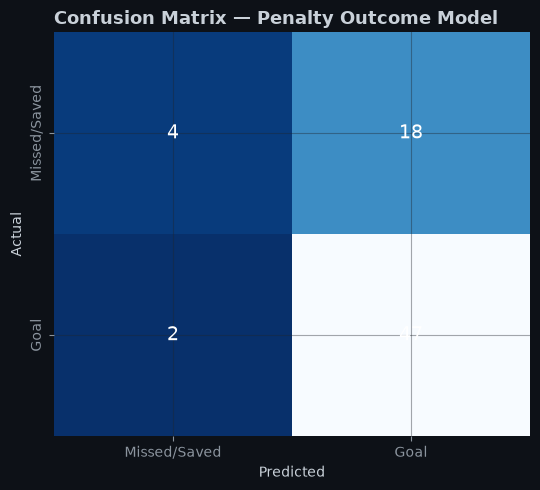

In [42]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r', cbar=False, ax=ax,
            xticklabels=['Missed/Saved', 'Goal'], yticklabels=['Missed/Saved', 'Goal'],
            annot_kws={'color': 'white', 'fontsize': 14})
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Penalty Outcome Model', loc='left')
plt.tight_layout()
plt.show()

**Honest read of the model:** an ROC-AUC close to 0.55 is only marginally better than a coin flip. That's not a failure of the modeling — it's the same conclusion the EDA already pointed to: the outcome of an individual penalty kick is dominated by factors this dataset doesn't capture (shooter technique, goalkeeper positioning, in-the-moment nerve), not by the game-state features available here (kick order, scoreline, stage). SHAP below shows what little signal the model *does* find.

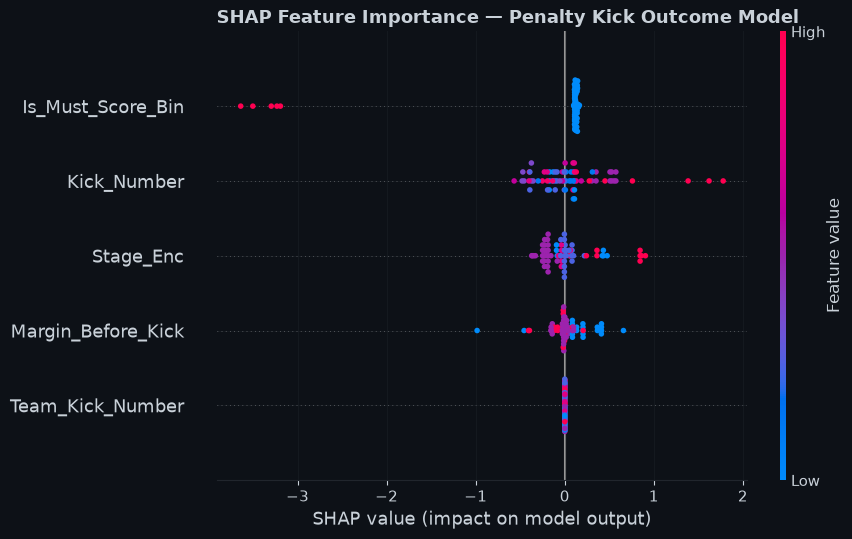

Feature importance ranking (mean |SHAP value|):
Is_Must_Score_Bin     0.3516
Kick_Number           0.2903
Stage_Enc             0.2050
Margin_Before_Kick    0.1289
Team_Kick_Number      0.0000


In [43]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(9, 5.5))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False, plot_size=None)
fig = plt.gcf()
fig.set_facecolor(BG)
for a in fig.axes:
    a.set_facecolor(BG)
    a.tick_params(colors=TEXT)
    a.xaxis.label.set_color(TEXT)
    a.yaxis.label.set_color(TEXT)
    a.title.set_color(TEXT)
plt.title('SHAP Feature Importance — Penalty Kick Outcome Model', loc='left', color=TEXT)
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
print("Feature importance ranking (mean |SHAP value|):")
print(mean_abs_shap.round(4).to_string())

`Is_Must_Score` is by far the strongest signal the model finds — consistent with the 17.6% vs. 71.6% conversion gap seen in the EDA above. `Kick_Number` and match stage contribute a modest secondary signal, `Margin_Before_Kick` less still, and which numbered kick within a team's own sequence (`Team_Kick_Number`) contributes essentially nothing. The overall picture reinforces that shootouts are close to random by design — which is arguably the point of using them as a tiebreaker — with real pressure on the sudden-death kick being the one exception.

<a id="execute"></a>
## 7️⃣ EXECUTE — Executive Summary

| Insight | Evidence |
|---|---|
| **The tournament has grown ~5.7x in matches** since 1930, but scoring efficiency has fallen | 18 → 64 matches; goals/match down from ~3.8 to ~2.5 |
| **Brazil, Germany, and Argentina anchor all-time scoring** | Top-3 nations account for a disproportionate share of the 2,400+ historical goals in this dataset |
| **Only a small minority of matches ever reach penalties** | Regular time still decides the vast majority of knockout matches |
| **The 2026 field spans a wide age range** | Youngest and oldest average squad ages differ by several years, hinting at contrasting national strategies (experience vs. legs) |
| **Centre-backs are the most-registered position** for 2026 | Defensive depth is prioritized over any other role across nearly every squad |
| **Penalty shootouts behave like near-random events** | ~69% baseline conversion rate holds fairly steady across kick order; the ML model tops out around AUC ≈ 0.55 |
| **Pressure is the one signal that survives modeling** | "Must-score" kicks convert at just 17.6%, vs. 71.6% for routine kicks — by far the largest single effect in the data, and it dominates SHAP importance |

<div style="background: linear-gradient(135deg, #0d1117 0%, #161b22 55%, #0d1117 100%); border: 1px solid #30363d; border-radius: 14px; padding: 34px 30px; margin-top: 10px;">
<div align="center">

<p style="color:#58a6ff; font-family:'Segoe UI',sans-serif; font-size:14px; font-weight:700; letter-spacing:2px; text-transform:uppercase; margin-bottom:4px;">End of Notebook</p>
<h3 style="color:#f0f6fc; font-family:'Segoe UI',sans-serif; margin-top:4px;">Thanks for reading ⚽</h3>
<p style="color:#8b949e; font-family:'Segoe UI',sans-serif; font-size:13.5px; max-width:520px; margin:10px auto;">If this analysis was useful, an upvote on Kaggle helps it reach more people. Feedback and forks are always welcome.</p>

<div style="margin-top:18px;">
<a href="https://www.kaggle.com/zohairbaloch" style="text-decoration:none; margin: 0 6px;"><span style="background:#20c997; color:#0d1117; padding:6px 16px; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:12.5px; font-weight:700;">📊 Kaggle</span></a>
<a href="https://github.com/zohairbaloch-64" style="text-decoration:none; margin: 0 6px;"><span style="background:#f0f6fc; color:#0d1117; padding:6px 16px; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:12.5px; font-weight:700;">💻 GitHub</span></a>
<a href="https://www.linkedin.com/in/zohair-baloch-data-analyst" style="text-decoration:none; margin: 0 6px;"><span style="background:#58a6ff; color:#0d1117; padding:6px 16px; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:12.5px; font-weight:700;">🔗 LinkedIn</span></a>
</div>

</div>
</div>